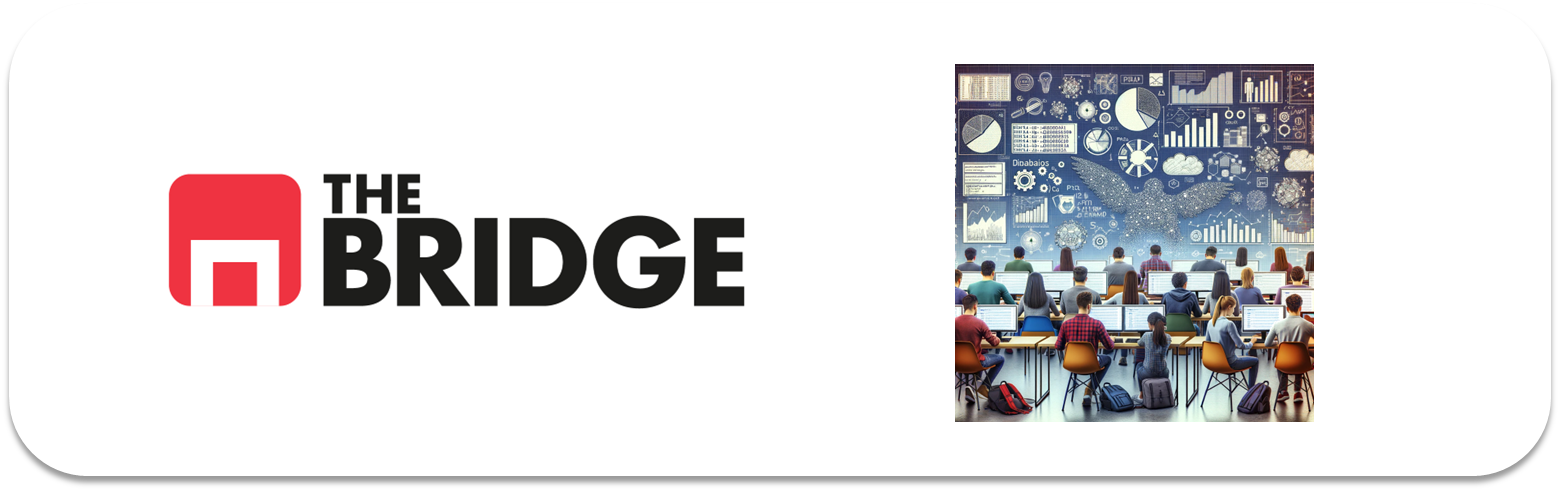

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
%matplotlib inline

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 




In [2]:
df = pd.read_csv("./data/titanic.csv")

2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.

In [3]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df.drop(columns=["sex", "deck", "pclass", "embarked", "adult_male", "alive"], inplace = True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   age          714 non-null    float64
 2   sibsp        891 non-null    int64  
 3   parch        891 non-null    int64  
 4   fare         891 non-null    float64
 5   class        891 non-null    str    
 6   who          891 non-null    str    
 7   embark_town  889 non-null    str    
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 56.7 KB


In [6]:
df.isnull().sum()

survived         0
age            177
sibsp            0
parch            0
fare             0
class            0
who              0
embark_town      2
alone            0
dtype: int64

3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.

<Axes: >

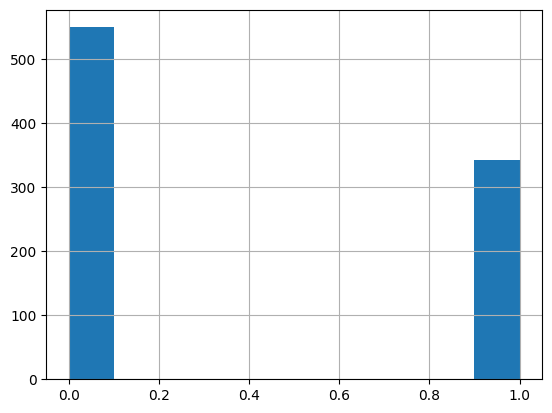

In [7]:
# seleccionamos la target
target = "survived"
# y la visualizamos en un histograma
df[target].hist()

In [8]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [9]:
# quitamos los dos nulos de embar_town para poder estratificar por esa columna
df = df.dropna(subset=["embark_town"])


In [10]:
df["embark_town"].isnull().sum()

np.int64(0)

In [11]:
from sklearn.model_selection import train_test_split

train_set , test_set = train_test_split(df, test_size=0.2, random_state=42, stratify = df["embark_town"])


5. Construye las parejas X,y de train y test.

In [12]:
target = "survived"

y_train = train_set[target]
y_test = test_set[target]

X_train = train_set.drop(columns=[target])
X_test = test_set.drop(columns=[target])

print(X_train.shape)
print(X_test.shape)

(711, 8)
(178, 8)


6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.

In [13]:
X_train.isnull().sum()

age            138
sibsp            0
parch            0
fare             0
class            0
who              0
embark_town      0
alone            0
dtype: int64

In [14]:
# imputar la media de age por cada grupo de who
X_train["age"] = X_train["age"].fillna(X_train.groupby("who")["age"].transform("mean"))


In [15]:
X_train.isnull().sum()

age            0
sibsp          0
parch          0
fare           0
class          0
who            0
embark_town    0
alone          0
dtype: int64

7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

In [16]:
def tipifica_variables(df: pd.DataFrame, umbral_categorica: int, umbral_continua: float) -> pd.DataFrame:
    """
    Clasifica las variables de un DataFrame según su cardinalidad y porcentaje de cardinalidad.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.
        umbral_categorica: Umbral para categorizar las variables categóricas
        umbral_continua: Float

    Retorna:
        pd.DataFrame: DataFrame con dos columnas: 'nombre_variable', 'tipo_sugerido'
        Retorna None si el input no es un DataFrame válido.
        Retorna None si el umbral_categorica no es un tipo válido (int).
        Retorna None si el umbral_continua no es un tipo válido (float)
    """
    
    # Comprobación de DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None
    
    # Comprobación umbral_categorica, debe ser entero positivo
    if not isinstance(umbral_categorica, int) or umbral_categorica <= 0:
        print("Error: umbral_categorica debe ser un entero positivo.")
        return None

    # comprobación umbral_continua, debe ser float entre 0 y 100
    if not isinstance(umbral_continua, float) or not (0 <= umbral_continua <= 100):
        print("Error: umbral_continua debe ser un float entre 0 y 100.")
        return None
    
    
    # Cardinalidad y porcentaje_cardinalidad
    cardinalidad = df.nunique()
    porcentaje_cardinalidad = df.nunique() / len(df) * 100

    # Clasificación variables
    tipos = []

    for col in df.columns:
        card = cardinalidad[col]
        pct = porcentaje_cardinalidad[col]

        if card == 2:
            tipo = "Binaria"

        elif card < umbral_categorica:
            tipo = "Categórica"

        elif card >= umbral_categorica and pct >= umbral_continua:
            tipo = "Numérica Continua"

        else:
            tipo = "Numérica Discreta"

        tipos.append(tipo)
    
    # DF resultado
    resultado = pd.DataFrame({
        "nombre_variable": df.columns,
        "tipo_sugerido": tipos
    })

    return resultado

In [17]:
tipifica_variables(X_train, 10, 0.3)

,nombre_variable,tipo_sugerido
0,age,Numérica Continua
1,sibsp,Categórica
2,parch,Categórica
3,fare,Numérica Continua
4,class,Categórica
5,who,Categórica
6,embark_town,Categórica
7,alone,Binaria


In [18]:
df.head()

,survived,age,sibsp,parch,fare,class,who,embark_town,alone
0,0,22.0,1,0,7.2500,Third,man,Southampton,False
1,1,38.0,1,0,71.2833,First,woman,Cherbourg,False
2,1,26.0,0,0,7.9250,Third,woman,Southampton,True
3,1,35.0,1,0,53.1000,First,woman,Southampton,False
4,0,35.0,0,0,8.0500,Third,man,Southampton,True


In [19]:
X_train.head()

,age,sibsp,parch,fare,class,who,embark_town,alone
46,32.965875,1,0,15.500,Third,man,Queenstown,False
230,35.000000,1,0,83.475,First,woman,Southampton,False
657,32.000000,1,1,15.500,Third,woman,Queenstown,False
888,31.625714,1,2,23.450,Third,woman,Southampton,False
809,33.000000,1,0,53.100,First,woman,Southampton,False


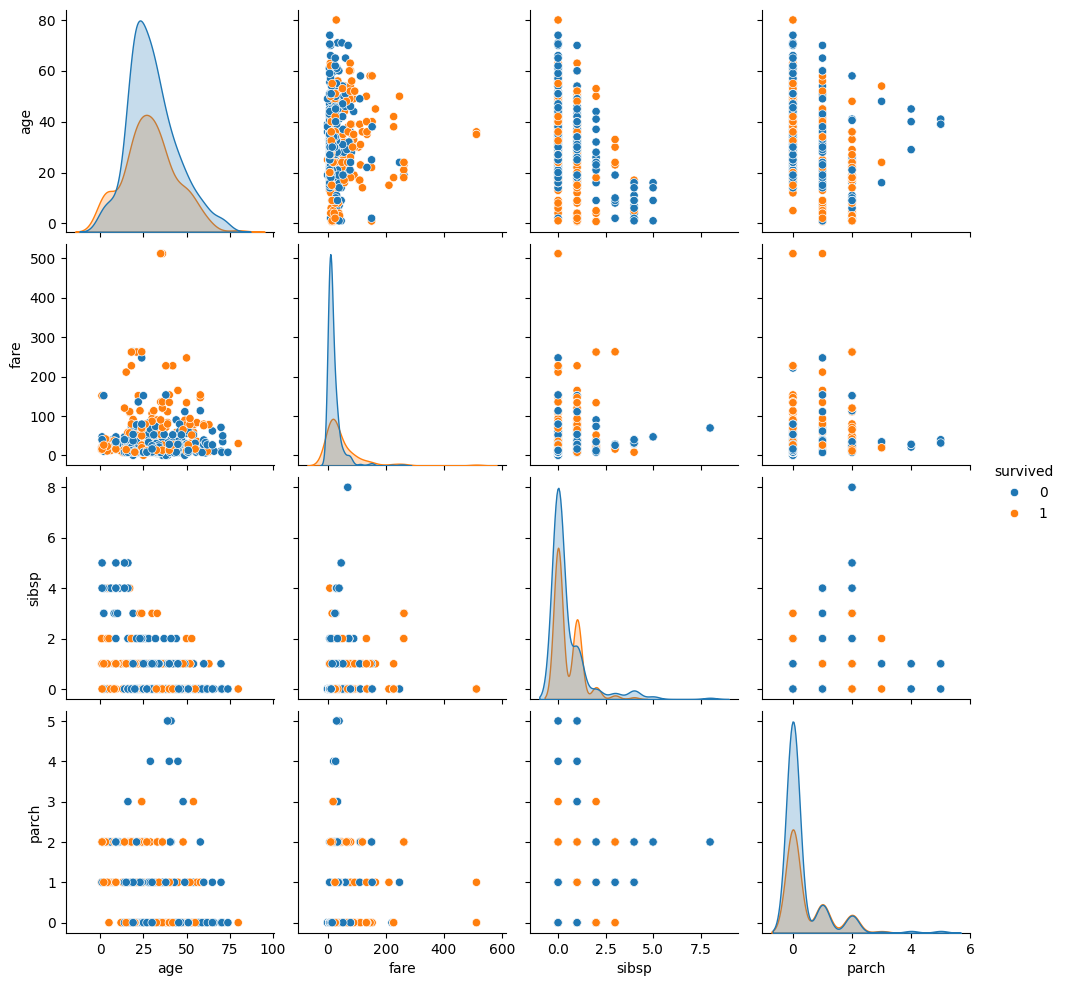

In [20]:
features_num = ["age", "fare", "sibsp", "parch"]

sns.pairplot(train_set[features_num + [target]], hue=target)


In [21]:
features_num = ["age", "fare", "sibsp"]

In [22]:
features_cat = ["class", "who", "embark_town", "alone"]

8. Trata las variables para que funcionen lo mejor posible en el modelo.

In [23]:
# hacemos una copia antes de tratar las variables
X_train_copy = X_train.copy()

In [24]:
X_train = pd.get_dummies(X_train, columns=features_cat, drop_first=False, dtype=int)

In [25]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 711 entries, 46 to 253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      711 non-null    float64
 1   sibsp                    711 non-null    int64  
 2   parch                    711 non-null    int64  
 3   fare                     711 non-null    float64
 4   class_First              711 non-null    int64  
 5   class_Second             711 non-null    int64  
 6   class_Third              711 non-null    int64  
 7   who_child                711 non-null    int64  
 8   who_man                  711 non-null    int64  
 9   who_woman                711 non-null    int64  
 10  embark_town_Cherbourg    711 non-null    int64  
 11  embark_town_Queenstown   711 non-null    int64  
 12  embark_town_Southampton  711 non-null    int64  
 13  alone_False              711 non-null    int64  
 14  alone_True               711 non-null    

In [26]:
X_train.head()

,age,sibsp,parch,fare,class_First,class_Second,class_Third,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,alone_False,alone_True
46,32.965875,1,0,15.500,0,0,1,0,1,0,0,1,0,1,0
230,35.000000,1,0,83.475,1,0,0,0,0,1,0,0,1,1,0
657,32.000000,1,1,15.500,0,0,1,0,0,1,0,1,0,1,0
888,31.625714,1,2,23.450,0,0,1,0,0,1,0,0,1,1,0
809,33.000000,1,0,53.100,1,0,0,0,0,1,0,0,1,1,0


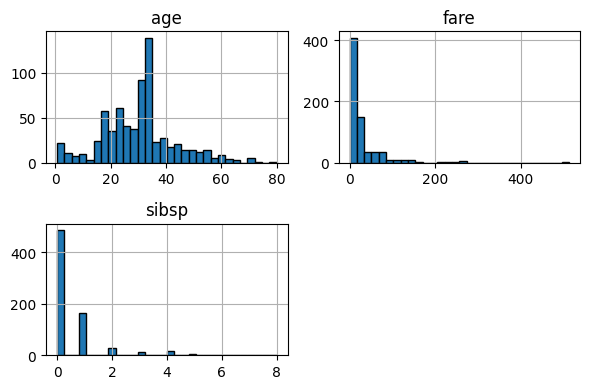

In [27]:
import matplotlib.pyplot as plt

X_train[features_num].hist(figsize=(6,4), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


In [28]:
# commprobamos asimetría
print("\n" + "=" * 60)
print("ASIMETRÍA DE FEATURES SELECCIONADAS")
print("=" * 60)

skew = X_train[features_num].skew().sort_values(ascending=False)

for feat, val in skew.items():
    flag = "→ transformar!" if abs(val) > 1 else "→ OK!"
    print(f"{feat:>8}  skew = {val:6.3f}  {flag}")



ASIMETRÍA DE FEATURES SELECCIONADAS
    fare  skew =  5.063  → transformar!
   sibsp  skew =  3.154  → transformar!
     age  skew =  0.375  → OK!


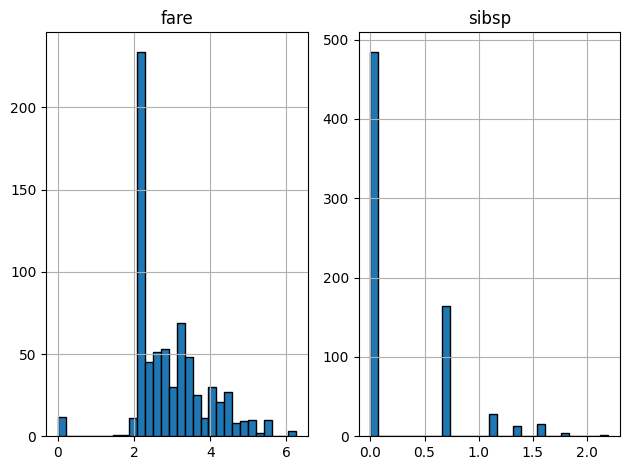

In [29]:
features_transform = ["fare", "sibsp"]

for feature in features_transform:
    train_set[feature] = train_set[feature].apply(np.log1p)

train_set[features_transform].hist(bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# se transforma y se entrena en train
X_train[features_num] = scaler.fit_transform(X_train[features_num])

# se transforma en test
X_test[features_num] = scaler.transform(X_test[features_num])


In [31]:
X_train[features_num].mean(), X_train[features_num].std()

(age      1.499035e-16
 fare    -3.747588e-17
 sibsp   -3.497749e-17
 dtype: float64,
 age      1.000704
 fare     1.000704
 sibsp    1.000704
 dtype: float64)

9. Construye un modelo de regresión logística.

In [32]:
from sklearn.linear_model import LogisticRegression

# instanciamos el modelo
clf = LogisticRegression(max_iter=5000) # como saber que valor pongo aquí?

# entrenamos el modelo
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.

In [33]:
clf.coef_

array([[-0.16905829, -0.59063404, -0.39730412,  0.25731799,  0.74125007,
         0.11216737, -0.85128458,  1.02363531, -2.03168776,  1.0101853 ,
         0.1198278 ,  0.11469125, -0.2323862 ,  0.20837913, -0.20624627]])

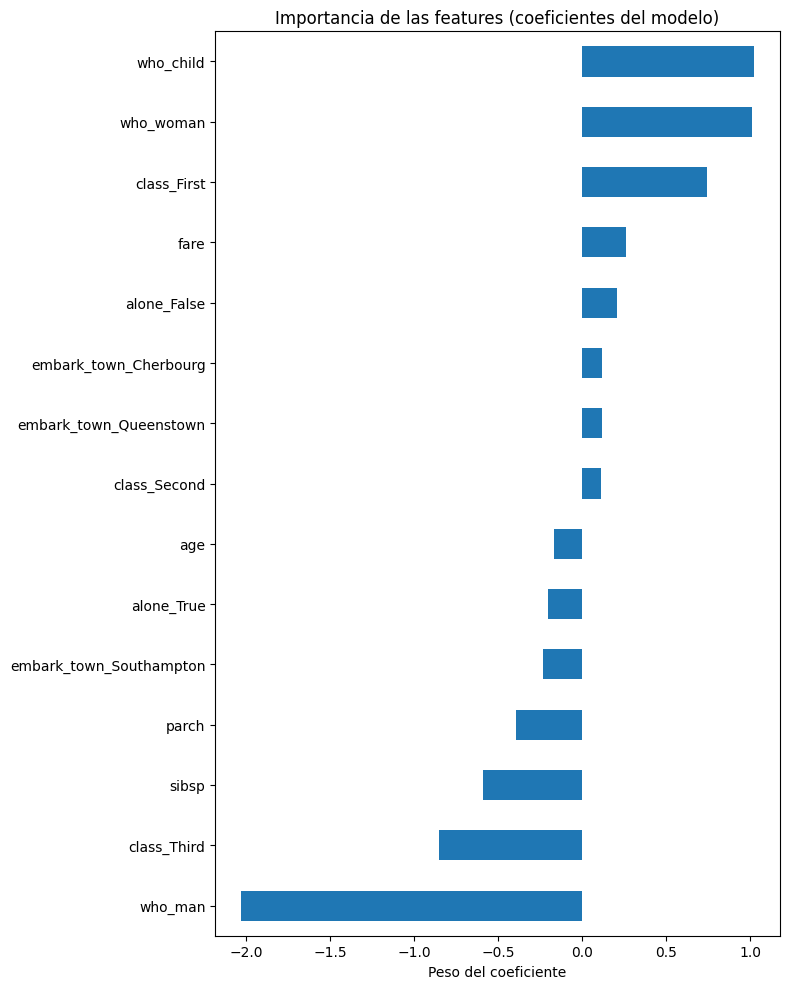

In [34]:
# dataframe con coeficientes
df_coefs = pd.DataFrame(clf.coef_[0], index=X_train.columns, columns=["coef"])

# ordenar por importancia absoluta
df_coefs_sorted = df_coefs.sort_values("coef")

# gráfico
plt.figure(figsize=(8, 10))
df_coefs_sorted["coef"].plot(kind="barh")
plt.title("Importancia de las features (coeficientes del modelo)")
plt.xlabel("Peso del coeficiente")
plt.tight_layout()
plt.show()


11. Procesa el dataset de Test para que puedas usarlo en la evaluación


In [35]:
X_train.columns

Index(['age', 'sibsp', 'parch', 'fare', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman',
       'embark_town_Cherbourg', 'embark_town_Queenstown',
       'embark_town_Southampton', 'alone_False', 'alone_True'],
      dtype='str')

In [38]:
X_test.columns

Index(['age', 'sibsp', 'parch', 'fare', 'class', 'who', 'embark_town',
       'alone'],
      dtype='str')

In [40]:
# Solucion para get_dummies en scikit-leran
# encoder = OneHotEncoder(handle_unknown ='ignore', sparse = False)


# LO QUE HACEMOS A TRAIN LO TENEMOS QUE HACER A TEST

# Imputamos los nulos de age por la media según who
X_test["age"] = X_test["age"].fillna(X_test.groupby("who")["age"].transform("mean"))

In [41]:
# hacemos el get dummies de las variables categoricas
X_test = pd.get_dummies(X_test, columns=features_cat, drop_first=False, dtype=int)

12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.

In [42]:
# predicciones para X_train
clf.predict(X_train)

array([0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In [43]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, clf.predict(X_train))
print(acc_train)

0.8354430379746836


In [44]:
# validamos el modelo, método de validación cruzada

from sklearn import model_selection
name='Logistic Regression'
cv_results = model_selection.cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
print(cv_results)
print(msg)

[0.82517483 0.8028169  0.84507042 0.85915493 0.83802817]
Logistic Regression: 0.834049 (0.019088)


In [60]:
y_test_pred = clf.predict(X_test)

In [54]:
y_train_pred = clf.predict(X_train)

In [47]:
accuracy_test = accuracy_score(y_test, y_pred)
accuracy_test


0.7752808988764045

In [56]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, balanced_accuracy_score,\
                            roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

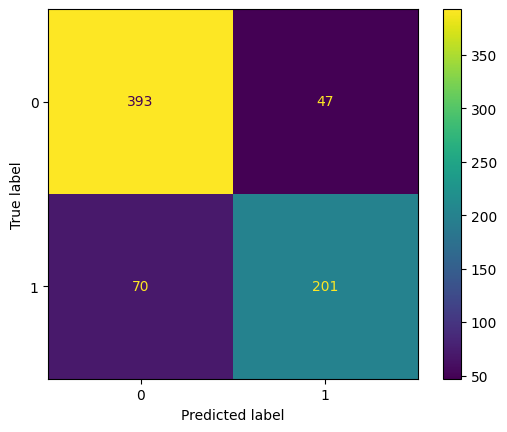

In [58]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)

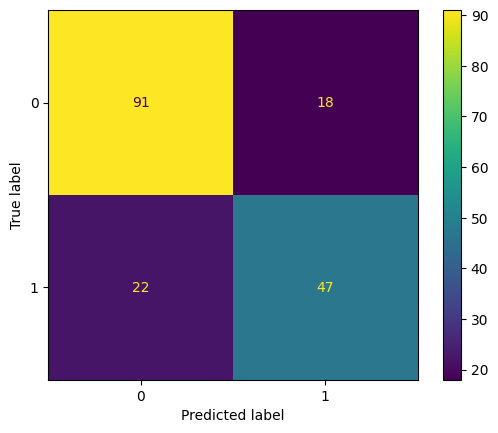

In [61]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       109
           1       0.72      0.68      0.70        69

    accuracy                           0.78       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.78      0.77       178



In [64]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       440
           1       0.81      0.74      0.77       271

    accuracy                           0.84       711
   macro avg       0.83      0.82      0.82       711
weighted avg       0.83      0.84      0.83       711



AUROC: 0.87


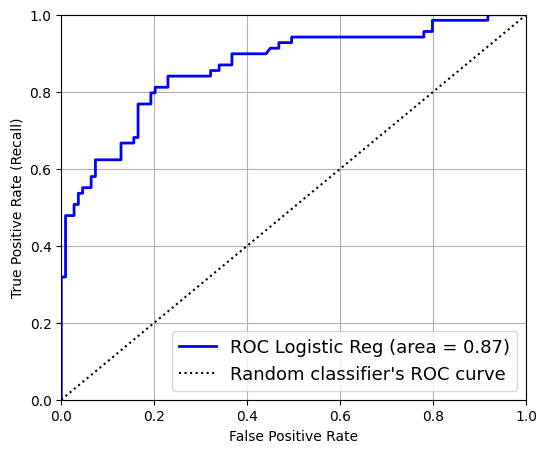

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades del modelo
scores = clf.predict_proba(X_test)

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, scores[:, 1])
roc_auc = auc(fpr, tpr)

print("AUROC: %.2f" % roc_auc)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, color="blue",
         label=f"ROC Logistic Reg (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.ylabel('True Positive Rate (Recall)')
plt.xlabel('False Positive Rate')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
plt.show()


13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.

14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  